## **Variables**

**Global Flag**		whether the customer has global offices

**Major Flag**		whether the customer is a large consumer in their industry (as opposed to SMC - Small Medium Corporation - or

**SMC Flag**		whether the customer is a Small Medium Corporation (SMC, as opposed to major and SMB)

**Commercial Flag**		whether the customer's business is commercial (as opposed to public secor)

**IT Spend**		$ spent on IT-related purchases

**Employee Count**		number of employees

**PC Count**		number of PCs used by the customer


**Size**		customer's size given by their yearly total revenue

**Tech Support**		whether the customer received tech support (binary)

**Discount**		whether the customer was given a discount (binary)

**Revenue**	$ Revenue from customer given by the amount of software purchased


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from dowhy import CausalModel

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [3]:
#load dataset
df = pd.read_csv('multi_attribution_sample.csv')

In [4]:
#preview dataset
df.head()

,Global Flag,Major Flag,SMC Flag,Commercial Flag,IT Spend,Employee Count,PC Count,Size,Tech Support,Discount,Revenue
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823


In [5]:
#rename columns
df.columns = ['global', 'major', 'smc', 'commercial', 'it_spend', 'employee_count', 'pc_count', 'size', 'tech_support', 'discount', 'revenue']

In [6]:
df.head()

,global,major,smc,commercial,it_spend,employee_count,pc_count,size,tech_support,discount,revenue
0,1,0,1,0,45537,26,26,152205,0,1,17688.36300
1,0,0,1,1,20842,107,70,159038,0,1,14981.43559
2,0,0,0,1,82171,10,7,264935,1,1,32917.13894
3,0,0,0,0,30288,40,39,77522,1,1,14773.76855
4,0,0,1,0,25930,37,43,91446,1,1,17098.69823


In [7]:
#check shape
df.shape

In [8]:
#check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   global          2000 non-null   int64  
 1   major           2000 non-null   int64  
 2   smc             2000 non-null   int64  
 3   commercial      2000 non-null   int64  
 4   it_spend        2000 non-null   int64  
 5   employee_count  2000 non-null   int64  
 6   pc_count        2000 non-null   int64  
 7   size            2000 non-null   int64  
 8   tech_support    2000 non-null   int64  
 9   discount        2000 non-null   int64  
 10  revenue         2000 non-null   float64
dtypes: float64(1), int64(10)
memory usage: 172.0 KB


In [9]:
#round the revenue column
df['revenue'] = df['revenue'].round(2)

In [10]:
# check summary statistics
df.describe()

,global,major,smc,commercial,it_spend,employee_count,pc_count,size,tech_support,discount,revenue
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.202000,0.1950,0.504500,0.691000,28272.703000,61.115000,57.345500,113159.120000,0.503000,0.510500,15397.917515
std,0.401593,0.3963,0.500105,0.462197,28207.138885,53.449707,52.861123,100987.600092,0.500116,0.500015,11290.944426
min,0.000000,0.0000,0.000000,0.000000,1161.000000,10.000000,6.000000,10101.000000,0.000000,0.000000,-616.570000
25%,0.000000,0.0000,0.000000,0.000000,8914.000000,24.000000,22.000000,39282.000000,0.000000,0.000000,7545.050000
50%,0.000000,0.0000,1.000000,1.000000,19210.500000,44.000000,41.000000,81378.000000,1.000000,1.000000,12582.445000
75%,0.000000,0.0000,1.000000,1.000000,37991.500000,79.000000,74.000000,155635.000000,1.000000,1.000000,19662.980000
max,1.000000,1.0000,1.000000,1.000000,259808.000000,535.000000,407.000000,766485.000000,1.000000,1.000000,86006.920000


In [11]:
# check value counts for tech support and discount
df.tech_support.value_counts()
df.discount.value_counts()

discount
1    1021
0     979
Name: count, dtype: int64

In [12]:
# check for missing values
df.isnull().sum()

global            0
major             0
smc               0
commercial        0
it_spend          0
employee_count    0
pc_count          0
size              0
tech_support      0
discount          0
revenue           0
dtype: int64

In [13]:
# check for duplicates
df.duplicated().sum()

0

In [20]:
# created new treatment variable for tech support and discount combined
df['tech_discount'] = np.where((df['tech_support'] == 1) & (df['discount'] == 1), 1, 0)
df.head()

,global,major,smc,commercial,it_spend,employee_count,pc_count,size,tech_support,discount,revenue,tech_discount
0,1,0,1,0,45537,26,26,152205,0,1,17688.36,0
1,0,0,1,1,20842,107,70,159038,0,1,14981.44,0
2,0,0,0,1,82171,10,7,264935,1,1,32917.14,1
3,0,0,0,0,30288,40,39,77522,1,1,14773.77,1
4,0,0,1,0,25930,37,43,91446,1,1,17098.70,1


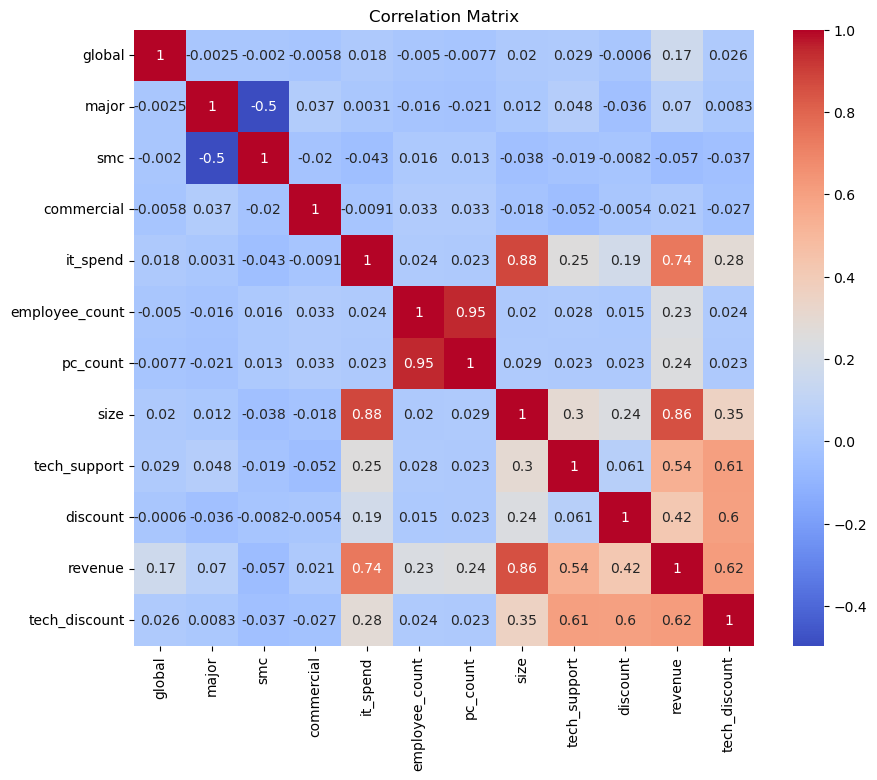

In [15]:
# correlation matrix
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

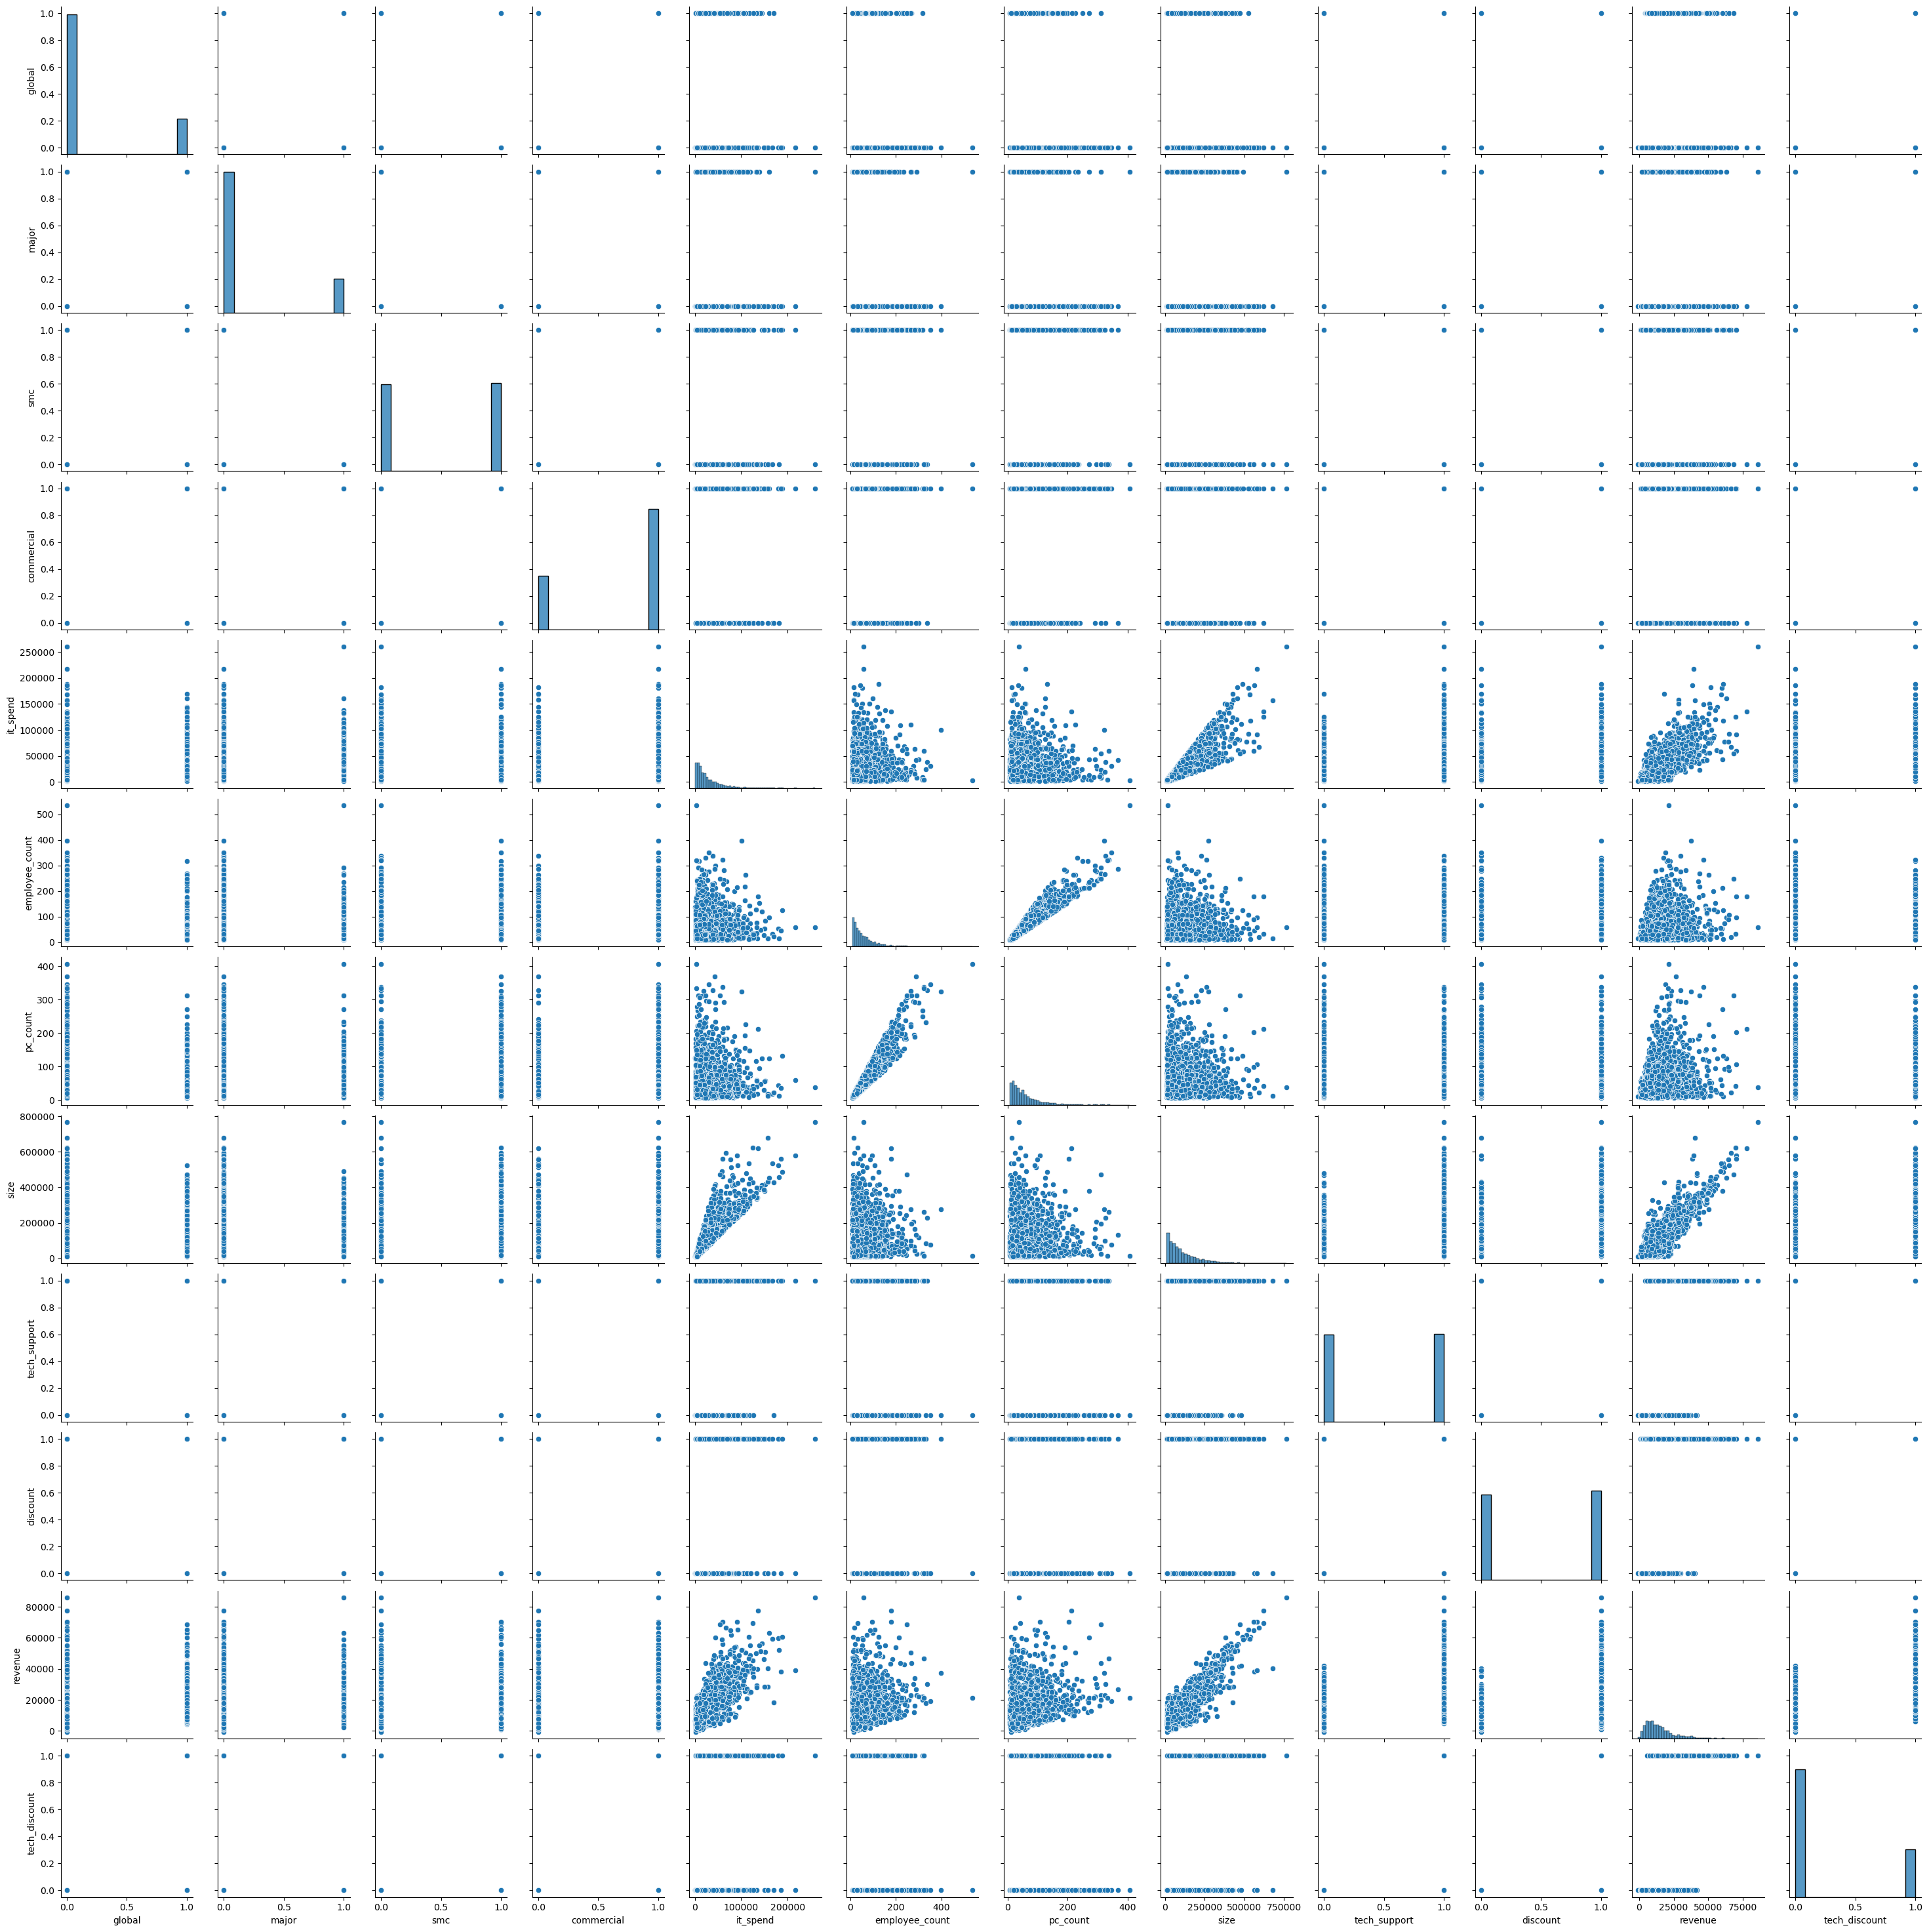

In [16]:
# pairplot
sns.pairplot(df)

<Axes: >

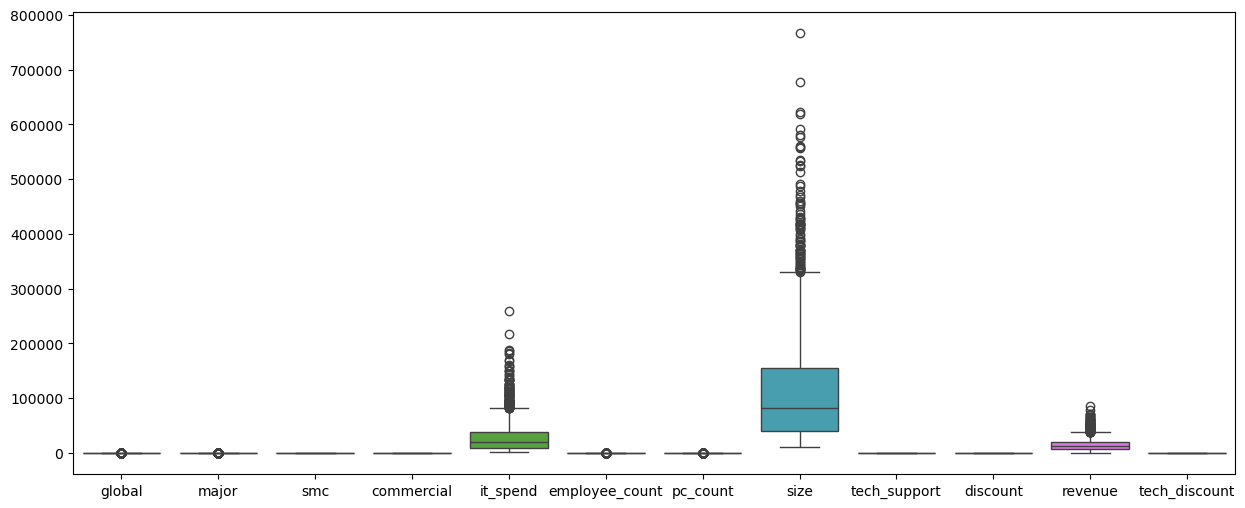

In [17]:
# check for outliers
plt.figure(figsize=(15, 6))
sns.boxplot(data=df)

In [22]:
# export dataframe to csv
df.to_csv('multi_attribution_update.csv', index=False)
